In [2]:
import os
from dotenv import load_dotenv
import praw

# wczytanie zmiennych z .env
load_dotenv()

def get_reddit():
    client_id = os.getenv("REDDIT_CLIENT_ID")
    client_secret = os.getenv("REDDIT_CLIENT_SECRET")
    user_agent = os.getenv("REDDIT_USER_AGENT")

    if not client_id or not client_secret or not user_agent:
        raise RuntimeError("Brakuje REDDIT_CLIENT_ID / REDDIT_CLIENT_SECRET / REDDIT_USER_AGENT w .env")

    reddit = praw.Reddit(
        client_id=client_id,
        client_secret=client_secret,
        user_agent=user_agent,
    )

    return reddit


# 1. Pozyskanie danych (15 pkt)

In [6]:
from collections import Counter
import pandas as pd
import time

reddit = get_reddit()

TOPICS = {
    "ai_content": {
        "keywords": [
            "ai generated", "generative ai", "deepfake", "chatgpt", "openai",
            "stable diffusion", "midjourney", "ai content"
        ]
    },
    "disinformation": {
        "keywords": [
            "disinformation", "fake news", "propaganda", "media manipulation",
            "conspiracy", "troll farm"
        ]
    },
    "mental_health_social": {
        "keywords": [
            "social media addiction", "screen time", "digital detox",
            "mental health", "body image", "internet addiction"
        ]
    }
}

RESULT = {}

for topic, cfg in TOPICS.items():
    print(f"\n=== BADAM TEMAT: {topic} ===")
    subreddit_counter = Counter()

    for kw in cfg["keywords"]:
        print(f"  - Szukam dla: '{kw}'")

        try:
            for submission in reddit.subreddit("all").search(
                kw, sort="new", limit=150
            ):
                subreddit_counter[str(submission.subreddit)] += 1
        except Exception as e:
            print(f"    [ERROR] {e}")

        time.sleep(1)

    RESULT[topic] = subreddit_counter
    print(f"Najczęstsze subreddity dla {topic}:")
    for sub, count in subreddit_counter.most_common(10):
        print(f"  r/{sub} → {count} wpisów")


rows = []
for topic, counter in RESULT.items():
    for sub, count in counter.items():
        rows.append({"topic": topic, "subreddit": sub, "count": count})

pd.DataFrame(rows).to_csv("data/discovered_subreddits.csv", index=False)
print("\nZapisano do data/discovered_subreddits.csv")



=== BADAM TEMAT: ai_content ===
  - Szukam dla: 'ai generated'
  - Szukam dla: 'generative ai'
  - Szukam dla: 'deepfake'
  - Szukam dla: 'chatgpt'
  - Szukam dla: 'openai'
  - Szukam dla: 'stable diffusion'
  - Szukam dla: 'midjourney'
  - Szukam dla: 'ai content'
Najczęstsze subreddity dla ai_content:
  r/midjourney → 52 wpisów
  r/ChatGPT → 36 wpisów
  r/StableDiffusion → 28 wpisów
  r/OpenAI → 24 wpisów
  r/bizhackers → 13 wpisów
  r/comfyui → 12 wpisów
  r/udemyfreebies → 11 wpisów
  r/SaaS → 10 wpisów
  r/aiwars → 9 wpisów
  r/grok → 9 wpisów

=== BADAM TEMAT: disinformation ===
  - Szukam dla: 'disinformation'
  - Szukam dla: 'fake news'
  - Szukam dla: 'propaganda'
  - Szukam dla: 'media manipulation'
  - Szukam dla: 'conspiracy'
  - Szukam dla: 'troll farm'
Najczęstsze subreddity dla disinformation:
  r/conspiracy → 41 wpisów
  r/complaints → 16 wpisów
  r/NewsRewind → 12 wpisów
  r/UsaNewsLive → 7 wpisów
  r/CreepCast_Submissions → 6 wpisów
  r/Destiny → 5 wpisów
  r/Candace

In [7]:
MIN_COUNT = 5      # minimalna liczba wystąpień, żeby sub był sensowny
MAX_SUBS = 8       # maksymalna liczba subredditów na temat

SUBREDDITS_BY_TOPIC = {}

for topic, counter in RESULT.items():
    # sortujemy od najczęstszych
    top_subs = [
        sub for sub, cnt in counter.most_common()
        if cnt >= MIN_COUNT
    ][:MAX_SUBS]

    SUBREDDITS_BY_TOPIC[topic] = top_subs

print("\n=== PROPOZYCJA SUBREDDITS_BY_TOPIC ===")
for topic, subs in SUBREDDITS_BY_TOPIC.items():
    print(f"{topic}: {subs}")



=== PROPOZYCJA SUBREDDITS_BY_TOPIC ===
ai_content: ['midjourney', 'ChatGPT', 'StableDiffusion', 'OpenAI', 'bizhackers', 'comfyui', 'udemyfreebies', 'SaaS']
disinformation: ['conspiracy', 'complaints', 'NewsRewind', 'UsaNewsLive', 'CreepCast_Submissions', 'Destiny', 'CandaceOwens', 'ArcRaiders']
mental_health_social: ['TalesFromTheCreeps', 'nosurf', 'Advice', 'HFY', 'AtlasBookClub', 'MotivationByDesign', 'SideProject', 'teenagers']


In [8]:
SUBREDDITS_BY_TOPIC = {
    "ai_content": [
        "midjourney",
        "ChatGPT",
        "StableDiffusion",
        "OpenAI",
        "comfyui",
        "ArtificialIntelligence",   # dodane ręcznie
        "MachineLearning",          # dodane ręcznie
        "technology"                # dodane ręcznie
    ],

    "disinformation": [
        "conspiracy",
        "news",
        "worldnews",
        "politics",
        "PoliticalDiscussion",
        "NewsRewind",      # z eksploracji
        "UsaNewsLive"      # z eksploracji
    ],

    "mental_health_social": [
        "nosurf",
        "Advice",
        "teenagers",
        "mentalhealth",    # dodane ręcznie
        "socialmedia",     # dodane ręcznie
        "SelfImprovement", # dodane ręcznie
        "internetaddiction" #  dodane ręcznie
    ],
}


## a) Lista użytkowników (5 pkt)

In [14]:
from collections import defaultdict
import os
import time

import pandas as pd

reddit = get_reddit()

# Zakładam, że TOPICS i SUBREDDITS_BY_TOPIC są już zdefiniowane powyżej

users = defaultdict(lambda: {"topics": set(), "subreddits": set()})

os.makedirs("data", exist_ok=True)

TARGET_PER_TOPIC = 300       # chcemy ok. 300 userów na temat
REQUEST_SLEEP = 1.0          # przerwa między zapytaniami
MAX_USERS_GLOBAL = 3000      # globalny limit bezpieczeństwa

for topic, cfg in TOPICS.items():
    keywords = cfg["keywords"]
    subreddits = SUBREDDITS_BY_TOPIC[topic]
    subreddits_str = "+".join(subreddits)

    users_from_topic = set()                         # unikalni userzy przypisani do tego tematu
    subreddits_covered = {s: set() for s in subreddits}  # z których subredditów mamy userów

    print(f"\n=== TEMAT: {topic} ===")
    print(f"Subreddits: {subreddits}")

    # -------- FAZA 1: zbieranie do ~TARGET_PER_TOPIC użytkowników --------
    for kw in keywords:
        if len(users_from_topic) >= TARGET_PER_TOPIC:
            break
        if len(users) >= MAX_USERS_GLOBAL:
            print("Osiągnięto globalny limit użytkowników, przerywam zbieranie.")
            break

        print(f"  [Faza 1] Szukam w [{subreddits_str}] dla frazy: '{kw}'")

        try:
            for submission in reddit.subreddit(subreddits_str).search(
                kw,
                sort="new",
                time_filter="year",
                limit=50,   # niższy limit, bo i tak mamy dużo danych
            ):
                if len(users_from_topic) >= TARGET_PER_TOPIC or len(users) >= MAX_USERS_GLOBAL:
                    break

                # autor posta
                author = submission.author
                if author and not getattr(author, "is_suspended", False):
                    uname = author.name
                    users[uname]["topics"].add(topic)
                    users[uname]["subreddits"].add(str(submission.subreddit))

                    users_from_topic.add(uname)

                    sub_name = str(submission.subreddit)
                    if sub_name in subreddits_covered:
                        subreddits_covered[sub_name].add(uname)

                # autorzy komentarzy (mocno ograniczamy, żeby nie wybuchło)
                try:
                    submission.comments.replace_more(limit=0)
                    comment_count = 0
                    for comment in submission.comments:
                        if len(users_from_topic) >= TARGET_PER_TOPIC or len(users) >= MAX_USERS_GLOBAL:
                            break
                        if comment_count >= 30:   # max 30 komentarzy na submission
                            break

                        c_author = comment.author
                        if c_author:
                            uname_c = c_author.name
                            users[uname_c]["topics"].add(topic)
                            users[uname_c]["subreddits"].add(str(comment.subreddit))

                            users_from_topic.add(uname_c)

                            c_sub_name = str(comment.subreddit)
                            if c_sub_name in subreddits_covered:
                                subreddits_covered[c_sub_name].add(uname_c)

                            comment_count += 1

                except Exception as e:
                    print(f"    [WARN] problem z komentarzami: {e}")

        except Exception as e:
            print(f"    [ERROR] problem przy szukaniu '{kw}': {e}")

        print(f"  > globalnie użytkowników: {len(users)} | w temacie '{topic}': {len(users_from_topic)}")
        time.sleep(REQUEST_SLEEP)

    print(f"\n--- Po FAZIE 1 tematu {topic}: {len(users_from_topic)} użytkowników ---")
    for sub, u_set in subreddits_covered.items():
        print(f"  r/{sub}: {len(u_set)} użytkowników")

    if len(users) >= MAX_USERS_GLOBAL:
        print("Osiągnięto globalny limit użytkowników, kończę iterację po tematach.")
        break

    # -------- FAZA 2: mała próba złapania kogokolwiek z brakujących subredditów --------
    missing_subreddits = [s for s, u_set in subreddits_covered.items() if len(u_set) == 0]
    if missing_subreddits:
        print(f"\n[Faza 2] Próba złapania userów z brakujących subredditów dla tematu '{topic}': {missing_subreddits}")

        for sub in missing_subreddits:
            if len(users) >= MAX_USERS_GLOBAL:
                break

            for kw in keywords[:3]:  # tylko kilka pierwszych keywordów, żeby nie przesadzać
                print(f"  [Faza 2] Szukam w r/{sub} dla frazy: '{kw}'")
                try:
                    for submission in reddit.subreddit(sub).search(
                        kw,
                        sort="new",
                        time_filter="year",
                        limit=20,  # mały limit, to tylko dogrywka
                    ):
                        if len(users) >= MAX_USERS_GLOBAL:
                            break

                        author = submission.author
                        if author and not getattr(author, "is_suspended", False):
                            uname = author.name
                            users[uname]["topics"].add(topic)
                            users[uname]["subreddits"].add(str(submission.subreddit))

                            users_from_topic.add(uname)
                            subreddits_covered[sub].add(uname)

                        # tu możemy już nie wchodzić w komentarze, żeby nie mnożyć danych
                    time.sleep(REQUEST_SLEEP)
                except Exception as e:
                    print(f"    [ERROR] problem przy szukaniu w r/{sub}: {e}")

    print(f"\n=== PODSUMOWANIE TEMATU {topic} ===")
    print(f"Użytkowników przypisanych do tematu: {len(users_from_topic)}")
    for sub, u_set in subreddits_covered.items():
        print(f"  r/{sub}: {len(u_set)} użytkowników")

# 5. Konwersja do DataFrame
rows = []
for username, info in users.items():
    rows.append({
        "username": username,
        "topics": ",".join(sorted(info["topics"])),
        "subreddits": ",".join(sorted(info["subreddits"]))
    })

df_users = pd.DataFrame(rows)

# 6. Zapis i podsumowanie
out_path = "data/users_reddit.csv"
df_users.to_csv(out_path, index=False, encoding="utf-8")

print(f"\nZapisano {len(df_users)} użytkowników do: {out_path}")
display(df_users.head())
len(df_users)



=== TEMAT: ai_content ===
Subreddits: ['midjourney', 'ChatGPT', 'StableDiffusion', 'OpenAI', 'comfyui', 'ArtificialIntelligence', 'MachineLearning', 'technology']
  [Faza 1] Szukam w [midjourney+ChatGPT+StableDiffusion+OpenAI+comfyui+ArtificialIntelligence+MachineLearning+technology] dla frazy: 'ai generated'
  > globalnie użytkowników: 263 | w temacie 'ai_content': 263
  [Faza 1] Szukam w [midjourney+ChatGPT+StableDiffusion+OpenAI+comfyui+ArtificialIntelligence+MachineLearning+technology] dla frazy: 'generative ai'
  > globalnie użytkowników: 264 | w temacie 'ai_content': 264
  [Faza 1] Szukam w [midjourney+ChatGPT+StableDiffusion+OpenAI+comfyui+ArtificialIntelligence+MachineLearning+technology] dla frazy: 'deepfake'
  > globalnie użytkowników: 300 | w temacie 'ai_content': 300

--- Po FAZIE 1 tematu ai_content: 300 użytkowników ---
  r/midjourney: 5 użytkowników
  r/ChatGPT: 105 użytkowników
  r/StableDiffusion: 53 użytkowników
  r/OpenAI: 53 użytkowników
  r/comfyui: 65 użytkownikó

,username,topics,subreddits
0,tylerthe-theatre,ai_content,technology
1,EffectiveHuman7450,ai_content,ChatGPT
2,AutoModerator,"ai_content,disinformation,mental_health_social","ChatGPT,conspiracy,nosurf,politics,socialmedia..."
3,Known-Rock8986,ai_content,comfyui
4,Adventurous-Date9971,ai_content,comfyui


977

## b) Pobranie aktywności użytkowników (5 pkt)

In [17]:
import os
import time
from math import ceil

import pandas as pd

reddit = get_reddit()

# 1. Wczytujemy użytkowników z 1a
df_users = pd.read_csv("data/users_reddit.csv")
print(f"Liczba użytkowników w pliku: {len(df_users)}")

# Możesz na czas testów ograniczyć liczbę userów:
# df_users = df_users.sample(100, random_state=42)

os.makedirs("data", exist_ok=True)

# Limity, żeby nie zabić API / nie mieć miliona rekordów
MAX_POSTS_PER_USER = 100
MAX_COMMENTS_PER_USER = 1000
SLEEP_BETWEEN_USERS = 0.5   # sekundy

rows = []

for i, row in df_users.iterrows():
    username = row["username"]
    user_topics = row.get("topics", "")
    user_subs_hint = row.get("subreddits", "")

    print(f"[{i+1}/{len(df_users)}] Pobieram aktywność u/{username}")

    try:
        redditor = reddit.redditor(username)

        # -------- POSTY (submissions) --------
        try:
            for j, post in enumerate(redditor.submissions.new(limit=MAX_POSTS_PER_USER)):
                rows.append({
                    "username": username,
                    "topics_from_userlist": user_topics,
                    "subreddits_from_userlist": user_subs_hint,
                    "type": "post",
                    "subreddit": str(post.subreddit),
                    "id": post.id,
                    "parent_id": None,
                    "link_id": post.id,  # dla postu link_id == id
                    "title": getattr(post, "title", None),
                    "body": getattr(post, "selftext", None),
                    "score": getattr(post, "score", None),
                    "ups": getattr(post, "ups", None),
                    "num_comments": getattr(post, "num_comments", None),
                    "created_utc": getattr(post, "created_utc", None),
                    "permalink": f"https://reddit.com{post.permalink}",
                })
        except Exception as e:
            print(f"  [WARN] problem z postami u/{username}: {e}")

        # -------- KOMENTARZE --------
        try:
            for j, comment in enumerate(redditor.comments.new(limit=MAX_COMMENTS_PER_USER)):
                rows.append({
                    "username": username,
                    "topics_from_userlist": user_topics,
                    "subreddits_from_userlist": user_subs_hint,
                    "type": "comment",
                    "subreddit": str(comment.subreddit),
                    "id": comment.id,
                    "parent_id": getattr(comment, "parent_id", None),
                    "link_id": getattr(comment, "link_id", None),
                    "title": None,
                    "body": getattr(comment, "body", None),
                    "score": getattr(comment, "score", None),
                    "ups": getattr(comment, "ups", None),
                    "num_comments": None,
                    "created_utc": getattr(comment, "created_utc", None),
                    "permalink": f"https://reddit.com{comment.permalink}",
                })
        except Exception as e:
            print(f"  [WARN] problem z komentarzami u/{username}: {e}")

    except Exception as e:
        print(f"  [ERROR] nie udało się pobrać redditor u/{username}: {e}")

    # mała pauza, żeby nie przekroczyć limitów
    time.sleep(SLEEP_BETWEEN_USERS)

print(f"\nZebrano łącznie {len(rows)} rekordów (posty + komentarze).")

df_activity = pd.DataFrame(rows)

out_path = "data/reddit_activity.csv"
df_activity.to_csv(out_path, index=False, encoding="utf-8")

print(f"Zapisano dane aktywności do: {out_path}")
display(df_activity.head())
len(df_activity)


Liczba użytkowników w pliku: 977
[1/977] Pobieram aktywność u/tylerthe-theatre
[2/977] Pobieram aktywność u/EffectiveHuman7450
[3/977] Pobieram aktywność u/AutoModerator
[4/977] Pobieram aktywność u/Known-Rock8986
[5/977] Pobieram aktywność u/Adventurous-Date9971
[6/977] Pobieram aktywność u/FugueSegue
[7/977] Pobieram aktywność u/Only4uArt
[8/977] Pobieram aktywność u/ckn
[9/977] Pobieram aktywność u/One-Hearing2926
[10/977] Pobieram aktywność u/EchoOfOppenheimer
[11/977] Pobieram aktywność u/War_Recent
[12/977] Pobieram aktywność u/MillyBoops
[13/977] Pobieram aktywność u/Larsmeatdragon
[14/977] Pobieram aktywność u/Warm_Practice_7000
[15/977] Pobieram aktywność u/eesnimi
[16/977] Pobieram aktywność u/ajsharm144
[17/977] Pobieram aktywność u/Scalchopz
[18/977] Pobieram aktywność u/Resident_Put_8934
[19/977] Pobieram aktywność u/threemenandadog
[20/977] Pobieram aktywność u/PrettyBasedMan
[21/977] Pobieram aktywność u/TheInfiniteUniverse_
[22/977] Pobieram aktywność u/hacktic
[23/977]

,username,topics_from_userlist,subreddits_from_userlist,type,subreddit,id,parent_id,link_id,title,body,score,ups,num_comments,created_utc,permalink
0,tylerthe-theatre,ai_content,technology,post,technology,1piyfxl,None,1piyfxl,"Somehow, this AI-generated McDonald’s ad about...",,1,1,1.0,1.765359e+09,https://reddit.com/r/technology/comments/1piyf...
1,tylerthe-theatre,ai_content,technology,post,london,1piy32v,None,1piy32v,Stuck in the slow lane: Average bus speed in L...,,9,9,31.0,1.765358e+09,https://reddit.com/r/london/comments/1piy32v/s...
2,tylerthe-theatre,ai_content,technology,post,technology,1pig579,None,1pig579,"Wizz the 'Tinder for kids' app, exposes kids t...",,3187,3187,381.0,1.765307e+09,https://reddit.com/r/technology/comments/1pig5...
3,tylerthe-theatre,ai_content,technology,post,unitedkingdom,1pidt6a,None,1pidt6a,'Thousands' turned away after private company ...,,494,494,112.0,1.765302e+09,https://reddit.com/r/unitedkingdom/comments/1p...
4,tylerthe-theatre,ai_content,technology,post,london,1pi8od5,None,1pi8od5,Londoners 'face overpriced East London ferry t...,,28,28,17.0,1.765290e+09,https://reddit.com/r/london/comments/1pi8od5/l...


476842

## c) Zapewnienie odpowiedniego rozmiaru zbioru (5 pkt)


=== PODSTAWOWE STATYSTYKI ZBIORU ===
Liczba wszystkich rekordów (posty + komentarze): 476842
Liczba unikalnych użytkowników w aktywności: 764
Liczba subredditów w zbiorze: 17564

=== PODZIAŁ NA TYP TREŚCI ===
type
comment    451496
post        25346
Name: count, dtype: int64

=== LICZBA REKORDÓW NA TEMAT ===
topic
disinformation          208725
ai_content              142612
mental_health_social    127705
dtype: int64

=== LICZBA REKORDÓW NA SUBREDDIT (TOP 10) ===
subreddit
teenagers          17572
conspiracy         14697
StableDiffusion     9151
Advice              8616
politics            8559
AskReddit           8459
ChatGPT             6022
comfyui             5524
NoFilterNews        3536
technology          2849
Name: count, dtype: int64


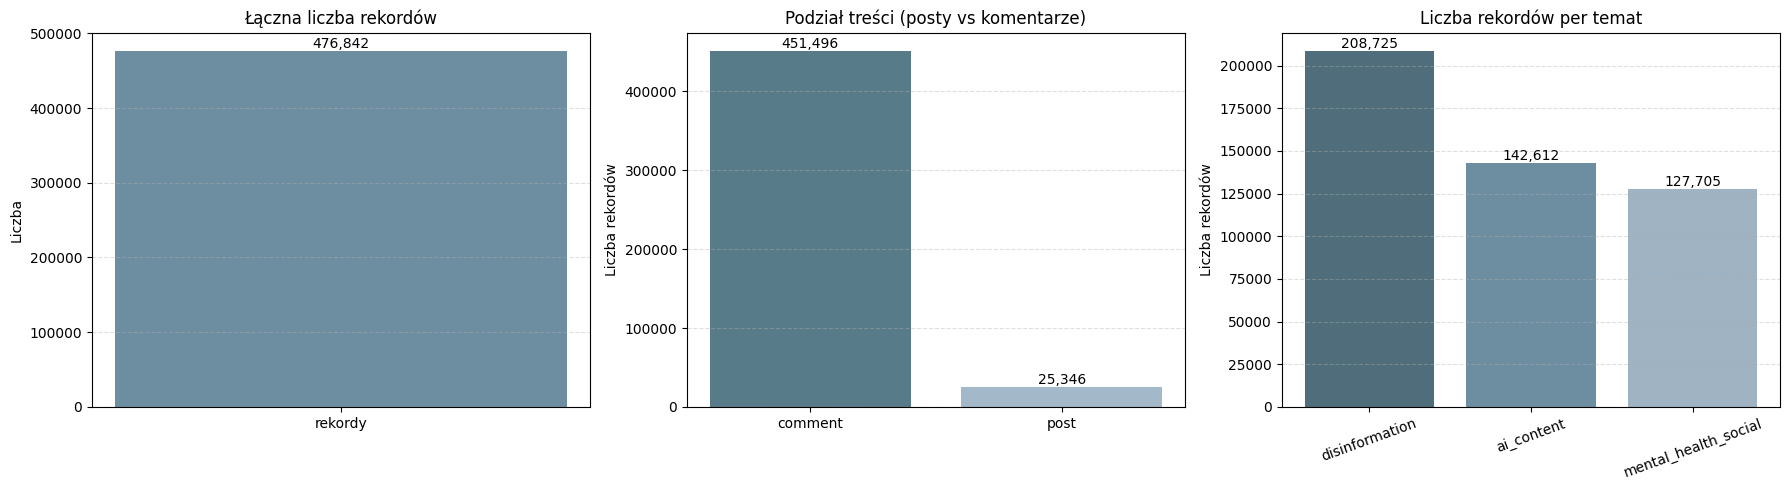

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Kolory zgodne ze stylem Biecka – stonowane, sensowne, spójne
color_total = "#6c8ea0"
colors_types = ["#587b89", "#a3b9c9"]
colors_topics = ["#4f6d7a", "#6c8ea0", "#9fb3c2"]
colors_basic = ["#6c8ea0"]                                # neutralny, stonowany
colors_two = ["#587b89", "#a3b9c9"]                       # dwie kategorie
colors_three = ["#4f6d7a", "#6c8ea0", "#9fb3c2"]           # trzy tematy

# Wczytanie danych
df = pd.read_csv("data/reddit_activity.csv")
total_records = len(df)
unique_users = df["username"].nunique()
unique_subreddits = df["subreddit"].nunique()
type_counts = df["type"].value_counts()

print("=== PODSTAWOWE STATYSTYKI ZBIORU ===")
print(f"Liczba wszystkich rekordów (posty + komentarze): {total_records}")
print(f"Liczba unikalnych użytkowników w aktywności: {unique_users}")
print(f"Liczba subredditów w zbiorze: {unique_subreddits}")

print("\n=== PODZIAŁ NA TYP TREŚCI ===")
print(type_counts)

print("\n=== LICZBA REKORDÓW NA TEMAT ===")
topic_counts = (
    df.assign(topic=df["topics_from_userlist"].str.split(","))
      .explode("topic")
      .groupby("topic")
      .size()
      .sort_values(ascending=False)
)
print(topic_counts)

print("\n=== LICZBA REKORDÓW NA SUBREDDIT (TOP 10) ===")
print(df["subreddit"].value_counts().head(10))
total_records = len(df)
type_counts = df["type"].value_counts()

topic_counts = (
    df.assign(topic=df["topics_from_userlist"].str.split(","))
      .explode("topic")
      .groupby("topic")
      .size()
      .sort_values(ascending=False)
)

# --- wykresy ---
plt.figure(figsize=(18, 5))

# 1️⃣ Łączna liczba rekordów
plt.subplot(1, 3, 1)
plt.bar(["rekordy"], [total_records], color=color_total)
plt.title("Łączna liczba rekordów")
plt.ylabel("Liczba")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.text(0, total_records, f"{total_records:,}", ha="center", va="bottom")

# 2️⃣ Podział na typ treści
plt.subplot(1, 3, 2)
bars = plt.bar(type_counts.index, type_counts.values, color=colors_two)
plt.title("Podział treści (posty vs komentarze)")
plt.ylabel("Liczba rekordów")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,}",
             ha="center", va="bottom")

# 3️⃣ Liczba rekordów per temat
plt.subplot(1, 3, 3)
bars2 = plt.bar(topic_counts.index, topic_counts.values, color=colors_three)
plt.title("Liczba rekordów per temat")
plt.ylabel("Liczba rekordów")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=20)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,}",
             ha="center", va="bottom")

plt.tight_layout()
plt.show()


# 2. Analiza wizualna pobranych danych (5 pkt)

## a) Interaktywny wykres liczby wpisów w czasie (2 pkt)


In [2]:
import pandas as pd
import plotly.express as px

SUBREDDITS_BY_TOPIC = {
    "ai_content": [
        "midjourney",
        "ChatGPT",
        "StableDiffusion",
        "OpenAI",
        "comfyui",
        "ArtificialIntelligence",
        "MachineLearning",
        "technology"
    ],
    "disinformation": [
        "conspiracy",
        "news",
        "worldnews",
        "politics",
        "PoliticalDiscussion",
        "NewsRewind",
        "UsaNewsLive"
    ],
    "mental_health_social": [
        "nosurf",
        "Advice",
        "teenagers",
        "mentalhealth",
        "socialmedia",
        "SelfImprovement",
        "internetaddiction"
    ],
}

subreddit_to_topic = {}
for topic, subs in SUBREDDITS_BY_TOPIC.items():
    for s in subs:
        subreddit_to_topic[s.lower()] = topic

df = pd.read_csv("data/reddit_activity.csv")

df["subreddit_norm"] = df["subreddit"].str.lower()
df["topic_from_subreddit"] = df["subreddit_norm"].map(subreddit_to_topic)

df_topic = df.dropna(subset=["topic_from_subreddit"]).copy()
df_topic["created_dt"] = pd.to_datetime(df_topic["created_utc"], unit="s")
df_topic["date"] = df_topic["created_dt"].dt.date

daily_topic_counts = (
    df_topic
    .groupby(["date", "topic_from_subreddit"])
    .size()
    .reset_index(name="count")
)

daily_all = (
    df_topic
    .groupby("date")
    .size()
    .reset_index(name="count")
)
daily_all["topic_from_subreddit"] = "WSZYSTKIE_TEMATY"

daily_combined = pd.concat([daily_topic_counts, daily_all], ignore_index=True)
daily_combined["date"] = pd.to_datetime(daily_combined["date"])


fig_activity = px.line(
    daily_combined,
    x="date",
    y="count",
    color="topic_from_subreddit",
    title="Aktywność w czasie dla tematów (na podstawie subredditów) oraz łącznie",
    labels={
        "date": "Data",
        "count": "Liczba wpisów (posty + komentarze)",
        "topic_from_subreddit": "Temat"
    }
)
fig_activity.update_layout(
    legend_title_text="Temat",
    hovermode="x unified"
)
fig_activity.update_xaxes(rangeslider_visible=True)

fig_activity.show()


## b) Analiza popularności wybranych użytkowników (3 pkt)

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("data/reddit_activity.csv")

SUBREDDITS_BY_TOPIC = {
    "ai_content": [
        "midjourney", "ChatGPT", "StableDiffusion", "OpenAI",
        "comfyui", "ArtificialIntelligence", "MachineLearning", "technology"
    ],
    "disinformation": [
        "conspiracy", "news", "worldnews", "politics",
        "PoliticalDiscussion", "NewsRewind", "UsaNewsLive"
    ],
    "mental_health_social": [
        "nosurf", "Advice", "teenagers", "mentalhealth",
        "socialmedia", "SelfImprovement", "internetaddiction"
    ],
}

# --- MAPOWANIE subreddita na temat ---
subreddit_to_topic = {}
for topic, subs in SUBREDDITS_BY_TOPIC.items():
    for s in subs:
        subreddit_to_topic[s.lower()] = topic

df["subreddit_norm"] = df["subreddit"].str.lower()
df["topic_from_subreddit"] = df["subreddit_norm"].map(subreddit_to_topic)
df_topic = df.dropna(subset=["topic_from_subreddit"]).copy()

df_topic["created_dt"] = pd.to_datetime(df_topic["created_utc"], unit="s")
df_topic["week"] = df_topic["created_dt"].dt.to_period("W").apply(lambda r: r.start_time)

# --- TOP 2 użytkowników per temat ---
top_users_by_topic = (
    df_topic.groupby(["topic_from_subreddit", "username"])["score"]
    .sum()
    .reset_index()
    .sort_values(["topic_from_subreddit", "score"], ascending=[True, False])
)

selected_users = (
    top_users_by_topic
    .groupby("topic_from_subreddit")
    .head(2)["username"]
    .unique()
    .tolist()
)

df_sel = df_topic[df_topic["username"].isin(selected_users)].copy()

# --- KLUCZOWA POPRAWKA ---
df_sel["user_topic_id"] = (
    df_sel["username"] + " [" + df_sel["topic_from_subreddit"] + "]"
)

weekly = (
    df_sel
    .groupby(["topic_from_subreddit", "user_topic_id", "week"])
    .agg(
        total_score=("score", "sum"),
        num_contents=("id", "count"),
        num_posts=("type", lambda s: (s == "post").sum()),
        post_comments_sum=("num_comments", lambda s: s.fillna(0).sum())
    )
    .reset_index()
)

weekly["engagement_index"] = (
    (weekly["total_score"] + weekly["post_comments_sum"]) /
    weekly["num_posts"].replace(0, 1)
)

metrics_long = weekly.melt(
    id_vars=["topic_from_subreddit", "user_topic_id", "week"],
    value_vars=["total_score", "num_contents", "post_comments_sum", "engagement_index"],
    var_name="metric",
    value_name="value"
)

metric_labels = {
    "total_score": "Suma ocen",
    "num_contents": "Liczba treści",
    "post_comments_sum": "Komentarze pod postami",
    "engagement_index": "Wskaźnik zaangażowania"
}
metrics_long["metric_label"] = metrics_long["metric"].map(metric_labels)

fig_users = px.line(
    metrics_long,
    x="week",
    y="value",
    color="user_topic_id",
    facet_col="metric_label",
    facet_col_wrap=2,
    title="Popularność użytkowników (rozbicie per temat) – TOP 2 z każdego tematu",
    labels={
        "week": "Tydzień",
        "value": "Wartość",
        "user_topic_id": "Użytkownik (Temat)"
    },
    hover_data={
        "topic_from_subreddit": True,
        "user_topic_id": True
    }
)

fig_users.update_layout(
    hovermode="x unified",
    legend_title_text="Użytkownik (Temat)"
)

for a in fig_users.layout.annotations:
    a.text = a.text.split("=")[-1]

fig_users.update_yaxes(matches=None)

for axis in fig_users.layout:
    if isinstance(getattr(fig_users.layout, axis), dict) and "yaxis" in axis:
        fig_users.layout[axis].showticklabels = True
        fig_users.layout[axis].title.text = "Wartość"

fig_users.show()



## **Metryki popularności użytkowników**

##### **1. Suma ocen (total_score)**

Łączna liczba punktów (upvote/downvote score) uzyskanych przez wpisy użytkownika w danym tygodniu.
Ocenia **jakość i odbiór treści**, ponieważ wysoki score oznacza, że posty były widoczne i pozytywnie przyjęte.

---

##### **2. Liczba treści (num_contents)**

Łączna liczba opublikowanych wpisów i komentarzy.
Mierzy **aktywność produkcyjną** — ilu treści użytkownik dostarcza społeczności.

---

##### **3. Komentarze pod postami (post_comments_sum)**

Łączna liczba komentarzy, które otrzymały posty użytkownika.
To wskaźnik **interakcji społeczności z jego treściami**, pokazujący, czy dyskusja „rozkręca się” wokół jego postów.

---

##### **4. Wskaźnik zaangażowania (engagement_index)**

$$[
\text{engagement} = \frac{\text{score + liczba komentarzy}}{\text{liczba postów}}
]$$

Łączy popularność (upvote'y) oraz interakcję (komentarze), normalizując je przez liczbę postów.
Pokazuje **średnie zaangażowanie generowane przez jeden post**, czyli miarę „siły oddziaływania” użytkownika.

---

In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import umap
import plotly.express as px

model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2",
    device="cuda" 
)

df_emb = df_topic.sample(1500, random_state=42).copy()
df_emb["text"] = df_emb["body"].fillna("")

emb = model.encode(
    df_emb["text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

In [9]:
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    metric="cosine",
)

coords = umap_model.fit_transform(emb)
df_emb["umap_x"] = coords[:, 0]
df_emb["umap_y"] = coords[:, 1]


In [10]:
fig = px.scatter(
    df_emb,
    x="umap_x",
    y="umap_y",
    color="topic_from_subreddit",
    hover_data=["username", "subreddit", "body"],
    title="Mapa semantyczna treści – lokalne embeddingi (MPNet) + UMAP"
)

fig.update_layout(legend_title_text="Temat")
fig.show()


# **Wnioski z analizy UMAP (lokalne embeddingi MPNet)**

* **1. Tematyka mental-health tworzy najbardziej zwarty i spójny klaster.**
  Widać wyraźnie, że wypowiedzi dotyczące zdrowia psychicznego mają podobny ton i słownictwo, dlatego naturalnie grupują się blisko siebie.

* **2. Disinformation oraz AI tworzą własne klastry, ale wyraźnie się przenikają.**
  Oba zbiory są bardziej zróżnicowane niż mental-health, mają zauważalne podgrupy i częściowo nakładają się na siebie w przestrzeni semantycznej.

* **3. Najszerszy i najbardziej rozciągnięty klaster reprezentuje tematykę AI.**
  Mimo że AI ma swój rdzeń, zajmuje dużą powierzchnię mapy, co sugeruje duży zakres tematów — od modeli językowych, przez deepfake’i, po techniczne dyskusje i memy.


In [20]:
import requests
import json
import time
from tqdm.auto import tqdm
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()
# ---------------------------------------------------------
# Load CLARIN API key and base URL (you provided this format)
# ---------------------------------------------------------
BASE_URL = "https://services.clarin-pl.eu"
API_KEY = os.getenv("CLARIN_TOKEN")  # If you're not in Colab, use env variable

# ---------------------------------------------------------
# CLARIN chat wrapper (your required format)
# ---------------------------------------------------------
def clarin_chat(model_id: str, messages, max_tokens: int = 512, temperature: float = 0.2):
    """
    Wrapper for CLARIN-PL LLM chat API (OpenAI-like).
    """
    url = f"{BASE_URL}/api/v1/oapi/chat/completions"
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "Accept": "application/json",
    }
    payload = {
        "model": model_id,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": temperature,
    }
    resp = requests.post(url, headers=headers, data=json.dumps(payload))
    resp.raise_for_status()
    data = resp.json()
    return data["choices"][0]["message"]["content"]

# ---------------------------------------------------------
# SAMPLE DATA FROM YOUR PIPELINE
# ---------------------------------------------------------
SAMPLE_SIZE = 400
df_llm = df_topic.sample(SAMPLE_SIZE, random_state=42).copy()
df_llm = df_llm.reset_index(drop=True)

# ---------------------------------------------------------
# Emotion + sentiment classifier using CLARIN LLM
# ---------------------------------------------------------
def classify_affect_clarin(text):
    """
    Uses the CLARIN-PL model 'clarin-affect-pllum' to classify:
    - sentiment (positive / neutral / negative)
    - dominant emotion
    - intensity (low / medium / high)

    Returns: (sentiment, emotion, intensity)
    """

    if not isinstance(text, str) or text.strip() == "":
        text = "(empty reddit message)"

    # System prompt rewritten fully in English
    system_prompt = (
        "You are an assistant that classifies emotional tone in Reddit messages.\n"
        "For the given text, produce a JSON object with three fields:\n"
        "1) 'sentiment' → one of: 'positive', 'neutral', 'negative'\n"
        "2) 'emotion' → dominant emotion, e.g. 'joy', 'sadness', 'anger', 'fear', "
        "'anxiety', 'calm', 'frustration', 'hope'\n"
        "3) 'intensity' → one of: 'low', 'medium', 'high'\n\n"
        "Return ONLY a JSON object. No explanations."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text[:1500]},
    ]

    # Execute CLARIN chat request
    response = clarin_chat(
        model_id="clarin-affect-pllum",
        messages=messages,
        max_tokens=128,
        temperature=0.0,   # deterministic
    )

    # -----------------------------------------------------
    # JSON FIXER — model may return extra text → extract JSON
    # -----------------------------------------------------
    try:
        data = json.loads(response)
    except Exception:
        cleaned = response.strip()
        start = cleaned.find("{")
        end = cleaned.rfind("}")
        if start != -1 and end != -1 and end > start:
            cleaned = cleaned[start:end+1]
        data = json.loads(cleaned)

    sentiment = data.get("sentiment")
    emotion = data.get("emotion")
    intensity = data.get("intensity")
    return sentiment, emotion, intensity

# ---------------------------------------------------------
# Run classification over sample
# ---------------------------------------------------------
sentiments = []
emotions = []
intensities = []

for text in tqdm(df_llm["body"].tolist(), desc="CLARIN Affect Classification"):
    try:
        s, e, i = classify_affect_clarin(text)
        print(classify_affect_clarin(text))
    except Exception:
        s, e, i = None, None, None
    sentiments.append(s)
    emotions.append(e)
    intensities.append(i)
    time.sleep(0.3)  # respect API limits

df_llm["llm_sentiment"] = sentiments
df_llm["llm_emotion"] = emotions
df_llm["llm_intensity"] = intensities

# ---------------------------------------------------------
# Save enriched dataset
# ---------------------------------------------------------
df_llm.to_csv("data/reddit_with_affect.csv", index=False)
df_llm.head()


CLARIN Affect Classification:   0%|          | 0/400 [00:00<?, ?it/s]

('negative', 'frustration', 'low')
('neutral', 'neutral', 'low')
('negative', 'anger', 'medium')
('negative', 'anger', 'medium')
('negative', 'sadness', 'low')
('negative', 'anger', 'low')
('neutral', 'joy', 'low')
('neutral', 'neutral', 'low')
('neutral', 'joy', 'low')
('neutral', 'frustration', 'low')
('negative', 'anger', 'low')
('neutral', 'joy', 'low')
('neutral', 'neutral', 'low')
('neutral', 'anger', 'low')
('positive', 'joy', 'medium')
('negative', 'anger', 'low')
('neutral', 'joy', 'low')
('negative', 'anger', 'low')
('negative', 'anger', 'medium')
('negative', 'anger', 'medium')
('negative', 'anger', 'low')
('negative', 'anger', 'high')
('negative', 'anger', 'high')
('positive', 'joy', 'medium')
('neutral', 'frustration', 'low')
('neutral', 'neutral', 'low')
('neutral', 'frustration', 'low')
('negative', 'anger', 'medium')
('neutral', 'anger', 'low')
('neutral', 'none', 'low')
('neutral', 'joy', 'low')
('neutral', 'neutral', 'low')
('negative', 'anger', 'low')
('negative', 'a

,username,topics_from_userlist,subreddits_from_userlist,type,subreddit,id,parent_id,link_id,title,body,...,num_comments,created_utc,permalink,subreddit_norm,topic_from_subreddit,created_dt,week,llm_sentiment,llm_emotion,llm_intensity
0,Only4uArt,ai_content,comfyui,comment,StableDiffusion,lw1yqk3,t3_1gmcqde,t3_1gmcqde,NaN,"everytime i think something looks impressive, ...",...,NaN,1.731059e+09,https://reddit.com/r/StableDiffusion/comments/...,stablediffusion,ai_content,2024-11-08 09:46:02,2024-11-04,negative,frustration,low
1,thomasangelo1508,mental_health_social,teenagers,comment,teenagers,nnaywhh,t3_1opeq0m,t3_1opeq0m,NaN,When I worked as an electrician this summer. I...,...,NaN,1.762376e+09,https://reddit.com/r/teenagers/comments/1opeq0...,teenagers,mental_health_social,2025-11-05 20:51:58,2025-11-03,neutral,neutral,low
2,AspiringOligarch,disinformation,conspiracy,comment,conspiracy,dk6ijhk,t1_dk63rhz,t3_6n25ut,NaN,> maybe it's for IT services\n\nIT? Is that an...,...,NaN,1.499974e+09,https://reddit.com/r/conspiracy/comments/6n25u...,conspiracy,disinformation,2017-07-13 19:22:17,2017-07-10,negative,anger,low
3,AccomplishedPoem9841,mental_health_social,Advice,comment,Advice,nroo3qk,t3_1pb8es3,t3_1pb8es3,NaN,"7 paragraphs that can be covered with: “hey, n...",...,NaN,1.764581e+09,https://reddit.com/r/Advice/comments/1pb8es3/r...,advice,mental_health_social,2025-12-01 09:30:40,2025-12-01,negative,anger,medium
4,EnigmaticKazoo5200,mental_health_social,teenagers,comment,teenagers,naqcewc,t1_naqbx89,t3_1n0getn,NaN,"Dw same here, it’s perfectly okay 😭 there are ...",...,NaN,1.756198e+09,https://reddit.com/r/teenagers/comments/1n0get...,teenagers,mental_health_social,2025-08-26 08:52:31,2025-08-25,negative,sadness,low


In [21]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import numpy as np
import plotly.express as px

df_llm = pd.read_csv("data/reddit_with_affect.csv")
df_llm = df_llm.dropna(subset=["body", "llm_emotion"]).reset_index(drop=True)

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

N = 800
df_u = df_llm.sample(min(N, len(df_llm)), random_state=42).copy()
texts = df_u["body"].fillna("").tolist()

emb = model.encode(texts, normalize_embeddings=True, show_progress_bar=True)

umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
coords = umap_model.fit_transform(emb)
df_u["umap_x"] = coords[:, 0]
df_u["umap_y"] = coords[:, 1]

fig = px.scatter(
    df_u,
    x="umap_x",
    y="umap_y",
    color="llm_emotion",
    hover_data=["username", "subreddit", "llm_sentiment", "body"],
    title="Semantic UMAP of Reddit messages coloured by LLM emotion"
)
fig.update_layout(legend_title_text="Emotion")
fig.show()


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

c:\Users\barrt\PycharmProjects\2025-zadanie-1-bmruszaj\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [36]:

fig_topic = px.scatter(
    df_u,
    x="umap_x",
    y="umap_y",
    color="topic_from_subreddit",
    hover_data=["username", "subreddit", "llm_emotion", "llm_sentiment", "body"],
    title="Semantic UMAP of Reddit messages coloured by high-level topic"
)
fig_topic.update_layout(legend_title_text="Topic")
fig_topic.show()


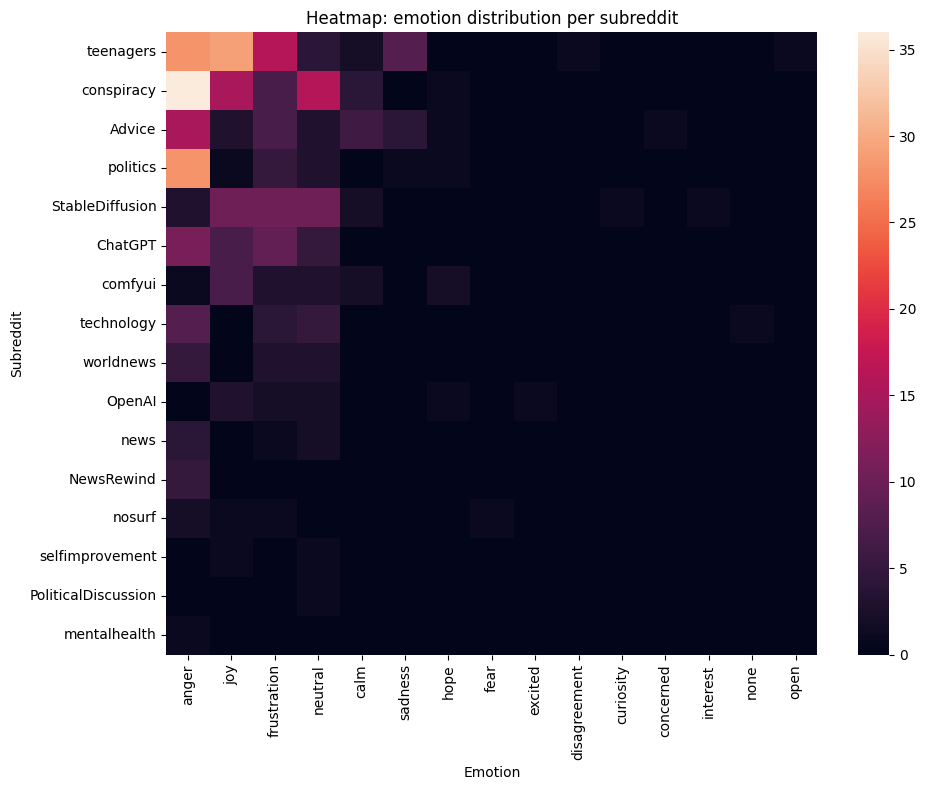

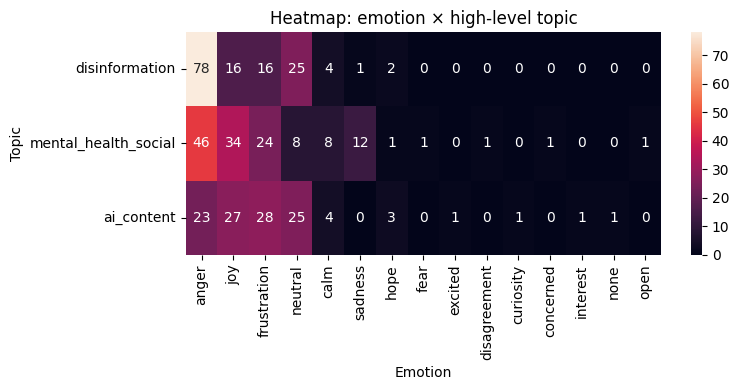

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

df_hm = df_llm.dropna(subset=["llm_emotion", "topic_from_subreddit"]).copy()
plt.figure(figsize=(10, 8))
sns.heatmap(table_sorted, annot=False)   # <- tu użyj table_sorted
plt.title("Heatmap: emotion distribution per subreddit")
plt.xlabel("Emotion")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

table_topic = pd.pivot_table(
    df_hm,
    index="topic_from_subreddit",
    columns="llm_emotion",
    values="body",
    aggfunc="count",
    fill_value=0
)

row_order_t = table_topic.sum(axis=1).sort_values(ascending=False).index
col_order_t = table_topic.sum(axis=0).sort_values(ascending=False).index
table_topic_sorted = table_topic.loc[row_order_t, col_order_t]

plt.figure(figsize=(8, 4))
sns.heatmap(table_topic_sorted, annot=True, fmt="d")   # <- tu użyj table_topic_sorted
plt.title("Heatmap: emotion × high-level topic")
plt.xlabel("Emotion")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()



# **Wnioski z heatmapy: emocje × tematy**

* **Disinformation**
  – dominuje **anger (78)**, wyraźnie więcej niż w innych tematach
  – silnie obecne także: **neutral**, **joy**, **frustration**
  – bardzo mało emocji pozytywnych typu *hope* czy *calm*

* **Mental health / social**
  – najbardziej zróżnicowany profil emocji
  – dużo **anger, joy i frustration**, ale także **sadness** i **anxiety/fear**
  – temat zawiera zarówno wpisy negatywne, jak i wspierające

* **AI content**
  – emocje najsłabsze ilościowo, ale względnie równomierne
  – najwięcej **joy, frustration i neutral**
  – prawie brak emocji silnie negatywnych (fear, sadness), co sugeruje mniejsze pobudzenie emocjonalne

---



In [31]:
df_spike = df_llm.dropna(subset=["llm_emotion"]).copy()
df_spike["created_dt"] = pd.to_datetime(df_spike["created_utc"], unit="s")
df_spike["week"] = df_spike["created_dt"].dt.to_period("W").apply(lambda r: r.start_time)
df_spike = df_spike[df_spike["created_dt"].dt.year >= 2025]

weekly_emotion = (
    df_spike.groupby(["week", "llm_emotion"])
    .size()
    .reset_index(name="count")
)

def detect_spikes(group):
    m = group["count"].mean()
    s = group["count"].std(ddof=0)
    threshold = m + 2 * s
    group["is_spike"] = group["count"] > threshold
    group["threshold"] = threshold
    return group

weekly_emotion = weekly_emotion.groupby("llm_emotion", group_keys=False).apply(detect_spikes)

fig_spike = px.line(
    weekly_emotion,
    x="week",
    y="count",
    color="llm_emotion",
    title="Emotion counts over time with spikes",
    labels={"week": "Week", "count": "Count", "llm_emotion": "Emotion"}
)

spike_points = weekly_emotion[weekly_emotion["is_spike"]]
fig_spike.add_scatter(
    x=spike_points["week"],
    y=spike_points["count"],
    mode="markers",
    marker=dict(size=10, symbol="circle-open"),
    name="Spike"
)

fig_spike.show()

weekly_emotion[weekly_emotion["is_spike"]].sort_values(["llm_emotion", "week"]).head()


C:\Users\barrt\AppData\Local\Temp\ipykernel_26408\1680130812.py:20: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,week,llm_emotion,count,is_spike,threshold
127,2025-12-01,anger,26,True,13.505968
87,2025-10-06,calm,2,True,1.875449
128,2025-12-01,calm,2,True,1.875449
129,2025-12-01,frustration,8,True,6.769686
131,2025-12-01,joy,13,True,8.254909



# ⚡ **UWAGA CIEKAWE ZASTOSOWANIE Emotional Spike Analysis!**

W tym etapie najpierw **wykrywamy nagłe skoki emocji (spikes)** w czasie, a następnie **wykorzystujemy model LLM do automatycznego podsumowania**, o czym użytkownicy dyskutowali podczas tych wybuchów emocjonalnych — pozwala to odkryć *ukryte wydarzenia, konflikty, reakcje społeczne i zmiany nastrojów* bez ręcznego przeglądania tysięcy komentarzy.

---

In [38]:
import pandas as pd
import json

def summarize_spike_emotion(emotion, week, model_id="llama3.3", max_examples=25):
    """
    Summarizes what people talked about during an emotion spike.
    """
    # wybieramy wszystkie rekordy z tej emocji i tego tygodnia
    df_sp = df_llm.copy()
    df_sp["created_dt"] = pd.to_datetime(df_sp["created_utc"], unit="s")
    df_sp["week"] = df_sp["created_dt"].dt.to_period("W").apply(lambda r: r.start_time)

    subset = df_sp[(df_sp["llm_emotion"] == emotion) & (df_sp["week"] == week)]
    subset = subset.dropna(subset=["body"])

    if subset.empty:
        return f"No messages found for {emotion} during spike at {week}"

    # wybieramy przykładowe wiadomości
    sample_comments = subset["body"].sample(min(max_examples, len(subset)), random_state=0).tolist()
    joined = "\n\n---\n\n".join(sample_comments)

    system_prompt = (
        "You are an expert analyst of Reddit discussions. "
        "You will receive comments posted during an emotion spike (a sudden rise in emotional intensity). "
        "Provide ONE short concise English sentence explaining:\n"
        "- what users were talking about,\n"
        "- what may have triggered the spike,\n"
        "- the dominant tone or linguistic pattern,\n"
        "- and whether the spike reflects support, conflict, stress, humor, or something else.\n"
        "Return exactly ONE insightful sentence."
    )


    user_prompt = (
        f"Emotion spike: {emotion}\nWeek: {week}\n\n"
        f"Here are the example comments:\n\n{joined}\n\n"
        "Provide a structured summary."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    return clarin_chat(model_id=model_id, messages=messages, max_tokens=350, temperature=0.2)


In [39]:
spikes = weekly_emotion[weekly_emotion["is_spike"]]

spike_summaries = []

for _, row in spikes.iterrows():
    emotion = row["llm_emotion"]
    week = row["week"]
    print(f"\n=== Summarizing spike: {emotion} ({week}) ===")
    summary = summarize_spike_emotion(emotion, week)
    spike_summaries.append({
        "emotion": emotion,
        "week": week,
        "summary": summary
    })
    print(summary)



=== Summarizing spike: calm (2025-10-06 00:00:00) ===
Users were discussing politics and a potential assassination attempt, possibly triggered by a news event or controversy, with a dominant tone of skepticism and conspiracy theories, reflecting a mix of conflict and stress, but with some comments suddenly shifting to a calm and instructional tone about a user interface issue.

=== Summarizing spike: neutral (2025-11-24 00:00:00) ===
Users were discussing various topics including software installation, philosophy, and politics, with the spike possibly triggered by a mention of a public figure, and the dominant tone is neutral with a mix of informative, appreciative, and speculative language, reflecting a sense of casual conversation and exchange of ideas.

=== Summarizing spike: anger (2025-12-01 00:00:00) ===
Users were discussing various topics, including relationships, vaccines, and online interactions, which may have triggered the anger spike due to disagreements and personal atta

In [40]:
pd.DataFrame(spike_summaries).to_csv("data/emotion_spike_summaries.csv", index=False)


In [34]:
import os
import json
from dotenv import load_dotenv
import requests

load_dotenv()
BASE_URL = "https://services.clarin-pl.eu"
API_KEY = os.getenv("CLARIN_TOKEN")

def clarin_chat(model_id: str, messages, max_tokens: int = 512, temperature: float = 0.2):
    url = f"{BASE_URL}/api/v1/oapi/chat/completions"
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "Accept": "application/json",
    }
    payload = {
        "model": model_id,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": temperature,
    }
    resp = requests.post(url, headers=headers, data=json.dumps(payload))
    resp.raise_for_status()
    data = resp.json()
    return data["choices"][0]["message"]["content"]

def explain_emotion_with_examples(emotion_label, n_examples=5, model_id="llama3.3"):
    subset = df_llm[df_llm["llm_emotion"] == emotion_label].dropna(subset=["body"])
    examples = subset.sample(min(n_examples, len(subset)), random_state=0)["body"].tolist()
    joined = "\n\n---\n\n".join(examples)
    print(f"\n=== EXAMPLES FOR EMOTION: {emotion_label} ===\n{joined}\n")

    system_prompt = (
        "You are an analyst of Reddit discussions. "
        "You receive several example comments and a target emotion label. "
        "Explain in clear English what this emotion typically looks like in this dataset: "
        "what people talk about, what linguistic cues or topics appear, and how intense it usually is."
    )
    user_prompt = (
        f"Emotion label: {emotion_label}\n\n"
        f"Here are example Reddit comments annotated with this emotion:\n\n{joined}\n\n"
        "Based on these examples, describe:\n"
        "1) What this emotion usually expresses in this data\n"
        "2) Typical topics and situations\n"
        "3) Typical wording or tone\n"
        "4) Whether it tends to be low, medium, or high intensity.\n"
    )
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    return clarin_chat(model_id=model_id, messages=messages, max_tokens=400, temperature=0.2)

print(explain_emotion_with_examples("joy", n_examples=5))



=== EXAMPLES FOR EMOTION: joy ===
Yep

---

I've seen people talk about this in other posts about SC. [Here is a page describing it](https://huggingface.co/blog/wuerstchen). When I did I Google search for it, I learned that Würstchen  is German for "hot dog"!

---

Okie dokie ✨

---

that’s a wild way to put it and i feel the metaphor heavy especially the dream part but that’s where i personally slow down cuz imagination don’t have to mean we’re literally inside someone else’s mind it might just mean consciousness can model reality without generating the hardware behind it but yeah the mystery of where the mind itself comes from is still the deepest question there is no matter what label you put on it

---

60% of the time, it works every time!

Based on the provided example comments annotated with the emotion label "joy", here's an analysis of what this emotion typically looks like in this dataset:

1. **What this emotion usually expresses**: The emotion of joy in this dataset often 